# VIX Forecast Ensemble

This notebook builds a leakage-safe ensemble from the baseline Transformer, RNN, ARIMAX, and XGBoost workflows. It intentionally does not use the `*_with_vix_price.ipynb` variants.

The base models generate out-of-fold predictions with the same expanding time-series folds. The stacked ensemble then predicts each fold using a meta-model trained only on earlier out-of-fold predictions, so neither the base models nor the meta-model are trained on the row being evaluated.


In [2]:
import random
import warnings

import numpy as np
import pandas as pd
try:
    import yahooquery as yq
except ImportError:
    yq = None

try:
    import yfinance as yf
except ImportError:
    yf = None

from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.21.0


## Load and Prep Data

This matches the baseline neural/ARIMA/XGBoost modeling window and excludes Reddit sentiment and the extra VIX-price feature variants.


In [3]:
MARKET_START = "1993-01-01"
MARKET_END = "2026-01-01"  # Set to None to pull the latest available market data.


def normalize_dates(values):
    dates = pd.to_datetime(values)
    if getattr(dates.dt, "tz", None) is not None:
        dates = dates.dt.tz_localize(None)
    return dates


def flatten_yahoo_columns(frame):
    out = frame.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [str(col[0]).lower().replace(" ", "") for col in out.columns]
    else:
        out.columns = [str(col).lower().replace(" ", "") for col in out.columns]
    return out


def effective_market_end(end=MARKET_END):
    if end is not None:
        return end
    return (pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def load_yahoo_adjclose(symbol, yf_symbol=None, start=MARKET_START, end=MARKET_END):
    end = effective_market_end(end)
    if yq is not None:
        try:
            hist = yq.Ticker(symbol).history(interval="1d", start=start, end=end).reset_index()
            if not hist.empty and "adjclose" in hist.columns:
                hist["date"] = normalize_dates(hist["date"])
                return hist[["date", "adjclose"]].copy()
        except Exception as exc:
            print(f"yahooquery failed for {symbol}; trying yfinance fallback. Error: {exc}")

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download market history.")

    download_symbol = yf_symbol or symbol
    hist = yf.download(download_symbol, start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    if "adjclose" not in hist.columns:
        raise ValueError(f"No adjusted-close column returned for {download_symbol}.")
    hist["date"] = normalize_dates(hist["date"])
    return hist[["date", "adjclose"]].copy()


def load_and_merge_data():
    gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
    gpr_df["date"] = pd.to_datetime(gpr_df["date"])

    vix = load_yahoo_adjclose("^VIX").rename(columns={"adjclose": "vix_adjclose"})
    spx = load_yahoo_adjclose("^SPX", yf_symbol="^GSPC").rename(columns={"adjclose": "spx_adjclose"})

    merged = (
        vix
        .merge(gpr_df, on="date", how="left")
        .merge(spx, on="date", how="left")
        .dropna()
    )
    merged = merged.sort_values("date").reset_index(drop=True)
    merged["vix_log_return"] = np.log(merged["vix_adjclose"]).diff()
    merged["spx_log_return"] = np.log(merged["spx_adjclose"]).diff()
    return merged.dropna().reset_index(drop=True)


df = load_and_merge_data()
print(f"Rows available: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows available: 8,306
Date range: 1993-01-05 to 2025-12-31


,date,vix_adjclose,GPRD,GPRD_ACT,GPRD_THREAT,spx_adjclose,vix_log_return,spx_log_return
0,1993-01-05,13.35,119.930664,82.456215,144.430908,434.339996,-0.000749,-0.002392
1,1993-01-06,13.37,84.319908,64.045990,106.841362,434.519989,0.001497,0.000414
2,1993-01-07,14.72,154.156281,71.479904,214.636658,430.730011,0.096194,-0.008760
3,1993-01-08,13.77,131.085571,105.958435,153.191666,429.049988,-0.066715,-0.003908
4,1993-01-11,12.86,149.133331,108.126747,180.376770,430.950012,-0.068371,0.004419


## Baseline Features

The ensemble uses the baseline feature set only: shifted GPR/SPX inputs, shifted rolling VIX log-return features, the day-gap feature, and one autoregressive VIX log-return lag. No extra VIX close-price features are included.


In [4]:
TARGET_COL = "vix_log_return"
LAG_COLS = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "spx_log_return"]
DEFAULT_ROLLING_WINDOWS = [21, 42, 365]
DEFAULT_ROLLING_SHIFTS = [1, 1, 1]
DEFAULT_ROLLING_STATS = "mean"
DEFAULT_ROLLING_TARGET_COLS = "vix_log_return"
AR_ORDER = 1
USE_AR_FEATURES = True


def add_lagged_exo_features(dataframe) -> pd.DataFrame:
    dataframe = dataframe.copy()
    for col in LAG_COLS:
        dataframe[f"{col.lower()}_shifted"] = dataframe[col].shift(1)
    return dataframe


def add_rolling_stats(
    frame: pd.DataFrame,
    windows: list[int],
    shifts: list[int],
    target_col: str | list[str] = "vix_log_return",
    stat: str | list[str] = "mean",
) -> pd.DataFrame:
    supported_stats = {"mean", "std", "min", "max"}

    if len(windows) != len(shifts):
        raise ValueError(f"`windows` and `shifts` must have the same length, got {len(windows)} and {len(shifts)}.")

    if isinstance(stat, str):
        if stat not in supported_stats:
            raise ValueError(f"Unsupported stat {stat!r}. Choose from {supported_stats}.")
        stats = [stat] * len(windows)
    else:
        if len(stat) != len(windows):
            raise ValueError(f"`stat` list must match length of `windows`, got {len(stat)} and {len(windows)}.")
        unsupported = set(stat) - supported_stats
        if unsupported:
            raise ValueError(f"Unsupported stats {unsupported}. Choose from {supported_stats}.")
        stats = list(stat)

    if isinstance(target_col, str):
        target_cols = [target_col] * len(windows)
    else:
        if len(target_col) != len(windows):
            raise ValueError(
                f"`target_col` list must match length of `windows`, got {len(target_col)} and {len(windows)}."
            )
        target_cols = list(target_col)

    missing = set(target_cols) - set(frame.columns)
    if missing:
        raise ValueError(f"Columns {missing} not found in frame.columns.")

    frame = frame.copy()
    for window, shift, s, col in zip(windows, shifts, stats, target_cols):
        rolled = frame[col].rolling(window=window, min_periods=window)
        series = getattr(rolled, s)()
        frame[f"{col}_{window}d_{s}_{shift}_shifted"] = series.shift(shift)
    return frame


def add_special_features(dataframe):
    dataframe = dataframe.copy()
    dataframe["days_since_last_trade"] = dataframe["date"].diff().dt.days.shift(1)
    return dataframe


def add_autoregressive_features(dataframe, p):
    dataframe = dataframe.copy()
    for i in range(p):
        dataframe[f"vix_log_return_shift_{i + 1}"] = dataframe["vix_log_return"].shift(i + 1)
    return dataframe


def build_modeling_frame(
    frame,
    windows=None,
    shifts=None,
    stats=None,
    target_cols=None,
    use_ar=USE_AR_FEATURES,
):
    full_df = frame.copy().reset_index(drop=True)
    if "_source_index" not in full_df.columns:
        full_df["_source_index"] = np.arange(len(full_df))

    full_df = add_lagged_exo_features(full_df)
    if use_ar:
        full_df = add_autoregressive_features(full_df, AR_ORDER)

    full_df = add_rolling_stats(
        full_df,
        windows=windows if windows is not None else DEFAULT_ROLLING_WINDOWS,
        shifts=shifts if shifts is not None else DEFAULT_ROLLING_SHIFTS,
        stat=stats if stats is not None else DEFAULT_ROLLING_STATS,
        target_col=target_cols if target_cols is not None else DEFAULT_ROLLING_TARGET_COLS,
    )
    full_df = add_special_features(full_df)
    full_df = full_df.dropna().reset_index(drop=True)

    feature_cols = [col for col in full_df.columns if col.endswith("_shifted")]
    if use_ar:
        feature_cols.extend([f"vix_log_return_shift_{i + 1}" for i in range(AR_ORDER)])
    return full_df, feature_cols


model_df, FEATURE_COLS = build_modeling_frame(df)
print(f"Rows available after feature engineering: {len(model_df):,}")
print(f"Feature count: {len(FEATURE_COLS)}")
model_df[["date", TARGET_COL, *FEATURE_COLS]].head()


Rows available after feature engineering: 7,941
Feature count: 8


,date,vix_log_return,gprd_threat_shifted,gprd_act_shifted,gprd_shifted,spx_log_return_shifted,vix_log_return_21d_mean_1_shifted,vix_log_return_42d_mean_1_shifted,vix_log_return_365d_mean_1_shifted,vix_log_return_shift_1
0,1994-06-15,-0.006920,146.418808,146.284454,132.062500,0.007097,-0.010757,-0.009128,-0.000387,-0.027213
1,1994-06-16,-0.026387,215.677032,110.817825,159.329315,-0.003814,-0.011510,-0.008220,-0.000404,-0.006920
2,1994-06-17,0.092714,161.396713,51.599552,122.927315,0.002862,-0.010812,-0.008420,-0.000480,-0.026387
3,1994-06-20,0.125784,177.530960,33.256508,120.093086,-0.007562,-0.000919,-0.007992,-0.000490,0.092714
4,1994-06-21,0.051651,211.360443,81.741867,163.988495,-0.006499,0.005912,-0.004593,0.000038,0.125784


## Model Configuration

In [5]:
LOOKBACK_DAYS = 20
BATCH_SIZE = 32
EPOCHS = 75
PATIENCE = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

RNN_HIDDEN_SIZE = 64
RNN_NUM_LAYERS = 1
RNN_DROPOUT = 0.0

TRANSFORMER_MODEL_DIM = 64
TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_FF_DIM = 128
TRANSFORMER_NUM_BLOCKS = 2
TRANSFORMER_DROPOUT = 0.1

N_SPLITS = 4
TEST_SIZE = 242
VALIDATION_SIZE = 242

ARIMAX_ORDER = (1, 1, 1)
XGB_PARAMS = {"random_state": RANDOM_SEED}

BASE_PRED_COLS = ["arimax_pred", "xgb_pred", "rnn_pred", "transformer_pred"]
ENSEMBLE_ALPHA = 1.0


## Neural Model Helpers

In [6]:
def eligible_target_indices(indices, lookback_days):
    return [int(idx) for idx in indices if int(idx) >= lookback_days - 1]


def split_train_validation(train_target_indices, validation_size=VALIDATION_SIZE):
    train_target_indices = list(train_target_indices)
    if len(train_target_indices) <= validation_size + 1:
        validation_size = max(1, len(train_target_indices) // 5)
    return train_target_indices[:-validation_size], train_target_indices[-validation_size:]


def build_sequence_arrays(frame, target_indices, feature_cols, target_col, feature_scaler, target_scaler, lookback_days):
    raw_features = frame[feature_cols].astype(np.float32)
    raw_targets = frame[[target_col]].astype(np.float32)
    features = feature_scaler.transform(raw_features).astype(np.float32)
    targets_scaled = target_scaler.transform(raw_targets).reshape(-1).astype(np.float32)
    targets_raw = raw_targets.to_numpy(dtype=np.float32).reshape(-1)

    x, y, y_raw, kept_indices = [], [], [], []
    for target_idx in target_indices:
        target_idx = int(target_idx)
        start_idx = target_idx - lookback_days + 1
        if start_idx < 0:
            continue
        x.append(features[start_idx:target_idx + 1])
        y.append(targets_scaled[target_idx])
        y_raw.append(targets_raw[target_idx])
        kept_indices.append(target_idx)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(y_raw, dtype=np.float32),
        np.asarray(kept_indices, dtype=int),
    )


def build_keras_rnn(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for layer_idx in range(RNN_NUM_LAYERS):
        return_sequences = layer_idx < RNN_NUM_LAYERS - 1
        x = layers.GRU(
            RNN_HIDDEN_SIZE,
            return_sequences=return_sequences,
            dropout=RNN_DROPOUT,
            recurrent_dropout=0.0,
        )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(RNN_HIDDEN_SIZE // 2, activation="gelu")(x)
    if RNN_DROPOUT > 0:
        x = layers.Dropout(RNN_DROPOUT)(x)
    outputs = layers.Dense(1)(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss="mse")
    return model


class NumericTokenAndPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, model_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.model_dim = model_dim
        self.value_projection = layers.Dense(model_dim)
        self.position_embedding = layers.Embedding(input_dim=sequence_length, output_dim=model_dim)

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        return self.value_projection(inputs) + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "model_dim": self.model_dim})
        return config


def build_keras_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = NumericTokenAndPositionEmbedding(
        sequence_length=input_shape[0],
        model_dim=TRANSFORMER_MODEL_DIM,
        name="token_position_embedding",
    )(inputs)

    for block_idx in range(TRANSFORMER_NUM_BLOCKS):
        attention_output = layers.MultiHeadAttention(
            num_heads=TRANSFORMER_NUM_HEADS,
            key_dim=TRANSFORMER_MODEL_DIM // TRANSFORMER_NUM_HEADS,
            dropout=TRANSFORMER_DROPOUT,
            name=f"self_attention_{block_idx + 1}",
        )(x, x)
        attention_output = layers.Dropout(TRANSFORMER_DROPOUT)(attention_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn_output = layers.Dense(TRANSFORMER_FF_DIM, activation="gelu")(x)
        ffn_output = layers.Dropout(TRANSFORMER_DROPOUT)(ffn_output)
        ffn_output = layers.Dense(TRANSFORMER_MODEL_DIM)(ffn_output)
        ffn_output = layers.Dropout(TRANSFORMER_DROPOUT)(ffn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D(name="sequence_pooling")(x)
    x = layers.Dense(TRANSFORMER_MODEL_DIM // 2, activation="gelu")(x)
    x = layers.Dropout(TRANSFORMER_DROPOUT)(x)
    outputs = layers.Dense(1)(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss="mse")
    return model


## Fold Prediction Helpers

In [7]:
def make_fold_data(train_idx, test_idx):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)
    full_idx = np.concatenate([train_idx, test_idx])

    fold_source_df = df.iloc[full_idx].copy()
    fold_source_df["_source_index"] = full_idx
    fold_model_df, feature_cols = build_modeling_frame(fold_source_df)

    train_target_indices = np.flatnonzero(fold_model_df["_source_index"].isin(train_idx)).astype(int)
    test_target_indices = np.flatnonzero(fold_model_df["_source_index"].isin(test_idx)).astype(int)
    train_target_indices = eligible_target_indices(train_target_indices, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_target_indices, LOOKBACK_DAYS)
    fit_target_indices, val_target_indices = split_train_validation(train_target_indices)

    if not fit_target_indices or not val_target_indices or not test_target_indices:
        raise ValueError("Fold does not have enough rows after feature engineering for train/validation/test sequences.")

    scaler_fit_idx = np.arange(max(fit_target_indices) + 1)
    feature_scaler = StandardScaler().fit(fold_model_df.iloc[scaler_fit_idx][feature_cols])
    target_scaler = StandardScaler().fit(fold_model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        fold_model_df, fit_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    val_arrays = build_sequence_arrays(
        fold_model_df, val_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    test_arrays = build_sequence_arrays(
        fold_model_df, test_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    return {
        "fold_model_df": fold_model_df,
        "feature_cols": feature_cols,
        "train_target_indices": np.asarray(train_target_indices, dtype=int),
        "fit_target_indices": np.asarray(fit_target_indices, dtype=int),
        "val_target_indices": np.asarray(val_target_indices, dtype=int),
        "test_target_indices": np.asarray(test_target_indices, dtype=int),
        "train_arrays": train_arrays,
        "val_arrays": val_arrays,
        "test_arrays": test_arrays,
        "target_scaler": target_scaler,
    }


def walk_forward_arimax(y_train, X_train, y_test, X_test):
    mod = SARIMAX(y_train, exog=X_train, order=ARIMAX_ORDER, trend="c")
    fitted = mod.fit(disp=False, method="lbfgs")
    preds = []
    for t in range(len(y_test)):
        pred = fitted.forecast(steps=1, exog=X_test.iloc[[t]])
        preds.append(float(pred.iloc[0]))
        fitted = fitted.append(y_test.iloc[[t]], exog=X_test.iloc[[t]])
    return np.asarray(preds, dtype=np.float64)


def fit_predict_xgb(y_train, X_train, X_test):
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    return model.predict(X_test).astype(np.float64)


def fit_predict_neural(build_fn, fold_data, seed_offset=0):
    x_train, y_train, _, _ = fold_data["train_arrays"]
    x_val, y_val, _, _ = fold_data["val_arrays"]
    x_test, _, _, _ = fold_data["test_arrays"]

    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED + seed_offset)
    model = build_fn(input_shape=(LOOKBACK_DAYS, len(fold_data["feature_cols"])))
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    pred_scaled = model.predict(x_test, verbose=0).reshape(-1)
    preds = fold_data["target_scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    return preds.astype(np.float64), history


def predict_base_models_for_fold(fold, train_idx, test_idx):
    fold_data = make_fold_data(train_idx, test_idx)
    frame = fold_data["fold_model_df"]
    feature_cols = fold_data["feature_cols"]
    train_target_indices = fold_data["train_target_indices"]
    test_target_indices = fold_data["test_target_indices"]

    X_train = frame.iloc[train_target_indices][feature_cols]
    y_train = frame.iloc[train_target_indices][TARGET_COL]
    X_test = frame.iloc[test_target_indices][feature_cols]
    y_test = frame.iloc[test_target_indices][TARGET_COL]

    arimax_pred = walk_forward_arimax(y_train, X_train, y_test, X_test)
    xgb_pred = fit_predict_xgb(y_train, X_train, X_test)
    rnn_pred, rnn_history = fit_predict_neural(build_keras_rnn, fold_data, seed_offset=1_000 + fold)
    transformer_pred, transformer_history = fit_predict_neural(
        build_keras_transformer, fold_data, seed_offset=10_000 + fold
    )

    out = pd.DataFrame({
        "fold": fold,
        "target_index": frame.iloc[test_target_indices]["_source_index"].to_numpy(dtype=int),
        "fold_row_index": test_target_indices,
        "date": frame.iloc[test_target_indices]["date"].to_numpy(),
        "actual": y_test.to_numpy(dtype=np.float64),
        "arimax_pred": arimax_pred,
        "xgb_pred": xgb_pred,
        "rnn_pred": rnn_pred,
        "transformer_pred": transformer_pred,
    })

    histories = {
        "rnn": pd.DataFrame({
            "fold": fold,
            "epoch": np.arange(1, len(rnn_history.history["loss"]) + 1),
            "train_loss": rnn_history.history["loss"],
            "val_loss": rnn_history.history["val_loss"],
        }),
        "transformer": pd.DataFrame({
            "fold": fold,
            "epoch": np.arange(1, len(transformer_history.history["loss"]) + 1),
            "train_loss": transformer_history.history["loss"],
            "val_loss": transformer_history.history["val_loss"],
        }),
    }
    return out, histories


## Generate Out-Of-Fold Base Predictions

Each base model is trained only on the expanding training portion of the fold, then predicts that fold's held-out rows. The meta-model is not fit in this cell.


In [8]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
fold_splits = list(tscv.split(df))

oof_frames = []
rnn_history_frames = []
transformer_history_frames = []

for fold, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    print(f"Fitting base models for fold {fold}/{len(fold_splits)}")
    fold_predictions, histories = predict_base_models_for_fold(fold, train_idx, test_idx)
    oof_frames.append(fold_predictions)
    rnn_history_frames.append(histories["rnn"])
    transformer_history_frames.append(histories["transformer"])

base_oof_df = pd.concat(oof_frames, ignore_index=True).sort_values(["fold", "date"]).reset_index(drop=True)
rnn_history_df = pd.concat(rnn_history_frames, ignore_index=True)
transformer_history_df = pd.concat(transformer_history_frames, ignore_index=True)

base_oof_df["simple_average_pred"] = base_oof_df[BASE_PRED_COLS].mean(axis=1)
base_oof_df.head()


Fitting base models for fold 1/4

Epoch 1/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0776 - val_loss: 1.5369
Epoch 2/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0052 - val_loss: 1.5214
Epoch 3/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9910 - val_loss: 1.5074
Epoch 4/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9823 - val_loss: 1.5034
Epoch 5/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9765 - val_loss: 1.5047
Epoch 6/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9717 - val_loss: 1.5090
Epoch 7/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9671 - val_loss: 1.5144
Epoch 8/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9623 - val_loss: 1.5201
Epoch 9/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9570 - val_loss: 1.5268
Epoch 10/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9510 - val_loss: 1.5346
Epoch 11/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9440 - val_loss: 1.5431
Epoch 12/75
210/21

,fold,target_index,fold_row_index,date,actual,arimax_pred,xgb_pred,rnn_pred,transformer_pred,simple_average_pred
0,1,7338,6973,2022-02-23,0.073910,0.017541,0.006111,-0.005158,-0.005366,0.003282
1,1,7339,6974,2022-02-24,-0.022825,-0.038272,0.010488,-0.007640,-0.008700,-0.011031
2,1,7340,6975,2022-02-25,-0.094354,-0.002407,0.005565,-0.004962,-0.004840,-0.001661
3,1,7341,6976,2022-02-28,0.088732,-0.012757,-0.003705,0.002691,-0.003585,-0.004339
4,1,7342,6977,2022-03-01,0.099973,-0.019877,0.001570,-0.005163,-0.005743,-0.007303


## Leakage-Safe Stacking Ensemble

The stacked ensemble for a fold is trained only on earlier folds' out-of-fold predictions. The first fold has no earlier meta-training rows, so it uses the simple average as a leakage-free bootstrap prediction.


In [9]:
ensemble_frames = []
for fold in sorted(base_oof_df["fold"].unique()):
    current = base_oof_df[base_oof_df["fold"].eq(fold)].copy()
    prior = base_oof_df[base_oof_df["fold"].lt(fold)].dropna(subset=BASE_PRED_COLS + ["actual"])

    if len(prior) > 0:
        meta_model = Ridge(alpha=ENSEMBLE_ALPHA)
        meta_model.fit(prior[BASE_PRED_COLS], prior["actual"])
        current["stacked_ensemble_pred"] = meta_model.predict(current[BASE_PRED_COLS])
        current["stacking_mode"] = "ridge_trained_on_prior_oof"
        for feature, coef in zip(BASE_PRED_COLS, meta_model.coef_):
            current[f"meta_coef_{feature}"] = coef
        current["meta_intercept"] = meta_model.intercept_
    else:
        current["stacked_ensemble_pred"] = current["simple_average_pred"]
        current["stacking_mode"] = "simple_average_bootstrap"
        for feature in BASE_PRED_COLS:
            current[f"meta_coef_{feature}"] = np.nan
        current["meta_intercept"] = np.nan

    ensemble_frames.append(current)

ensemble_oof_df = pd.concat(ensemble_frames, ignore_index=True).sort_values(["fold", "date"]).reset_index(drop=True)
ensemble_oof_df.head()


,fold,target_index,fold_row_index,date,actual,arimax_pred,xgb_pred,rnn_pred,transformer_pred,simple_average_pred,stacked_ensemble_pred,stacking_mode,meta_coef_arimax_pred,meta_coef_xgb_pred,meta_coef_rnn_pred,meta_coef_transformer_pred,meta_intercept
0,1,7338,6973,2022-02-23,0.073910,0.017541,0.006111,-0.005158,-0.005366,0.003282,0.003282,simple_average_bootstrap,NaN,NaN,NaN,NaN,NaN
1,1,7339,6974,2022-02-24,-0.022825,-0.038272,0.010488,-0.007640,-0.008700,-0.011031,-0.011031,simple_average_bootstrap,NaN,NaN,NaN,NaN,NaN
2,1,7340,6975,2022-02-25,-0.094354,-0.002407,0.005565,-0.004962,-0.004840,-0.001661,-0.001661,simple_average_bootstrap,NaN,NaN,NaN,NaN,NaN
3,1,7341,6976,2022-02-28,0.088732,-0.012757,-0.003705,0.002691,-0.003585,-0.004339,-0.004339,simple_average_bootstrap,NaN,NaN,NaN,NaN,NaN
4,1,7342,6977,2022-03-01,0.099973,-0.019877,0.001570,-0.005163,-0.005743,-0.007303,-0.007303,simple_average_bootstrap,NaN,NaN,NaN,NaN,NaN


## OOF Metrics

In [10]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    actual_rise = (actual > 0).astype(int)
    predicted_rise = (predicted > 0).astype(int)
    mse = mean_squared_error(actual, predicted)
    metrics = {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
        "swing_accuracy": float(accuracy_score(actual_rise, predicted_rise)),
    }
    if len(np.unique(actual_rise)) > 1:
        metrics["swing_balanced_accuracy"] = float(balanced_accuracy_score(actual_rise, predicted_rise))
    else:
        metrics["swing_balanced_accuracy"] = np.nan
    return metrics


MODEL_PREDICTION_COLUMNS = {
    "arimax": "arimax_pred",
    "xgboost": "xgb_pred",
    "rnn": "rnn_pred",
    "transformer": "transformer_pred",
    "simple_average": "simple_average_pred",
    "stacked_ensemble": "stacked_ensemble_pred",
}


def summarize_predictions(frame, include_bootstrap_fold=True):
    rows = []
    eval_frame = frame.copy()
    if not include_bootstrap_fold:
        eval_frame = eval_frame[eval_frame["stacking_mode"].ne("simple_average_bootstrap")]

    for model_name, pred_col in MODEL_PREDICTION_COLUMNS.items():
        metrics = regression_metrics(eval_frame["actual"], eval_frame[pred_col])
        rows.append({"model": model_name, "rows": len(eval_frame), **metrics})
    return pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)


oof_metrics_df = summarize_predictions(ensemble_oof_df, include_bootstrap_fold=True)
stacked_no_bootstrap_metrics_df = summarize_predictions(ensemble_oof_df, include_bootstrap_fold=False)

print("OOF metrics including fold-1 simple-average bootstrap:")
display(oof_metrics_df)

print("OOF metrics excluding fold-1 bootstrap rows:")
display(stacked_no_bootstrap_metrics_df)


OOF metrics including fold-1 simple-average bootstrap:


,model,rows,mse,rmse,mae,r2,swing_accuracy,swing_balanced_accuracy
0,transformer,968,0.005333,0.073030,0.050247,0.010801,0.553719,0.536364
1,rnn,968,0.005349,0.073139,0.050441,0.007863,0.557851,0.568995
2,simple_average,968,0.005387,0.073394,0.050626,0.000936,0.545455,0.543732
3,stacked_ensemble,968,0.005413,0.073575,0.050428,-0.004004,0.553719,0.517129
4,xgboost,968,0.006073,0.077933,0.055049,-0.126455,0.537190,0.538182
5,arimax,968,0.006246,0.079030,0.055933,-0.158391,0.510331,0.504498


OOF metrics excluding fold-1 bootstrap rows:


,model,rows,mse,rmse,mae,r2,swing_accuracy,swing_balanced_accuracy
0,transformer,726,0.005838,0.076408,0.051391,0.013941,0.542700,0.534525
1,simple_average,726,0.005875,0.076648,0.051824,0.007734,0.542700,0.548081
2,rnn,726,0.005875,0.076652,0.051782,0.007629,0.544077,0.560154
3,stacked_ensemble,726,0.005910,0.076879,0.051560,0.001736,0.553719,0.517919
4,xgboost,726,0.006536,0.080846,0.056294,-0.103945,0.530303,0.533974
5,arimax,726,0.006686,0.081770,0.056653,-0.129330,0.522039,0.517453


## Fold Plots

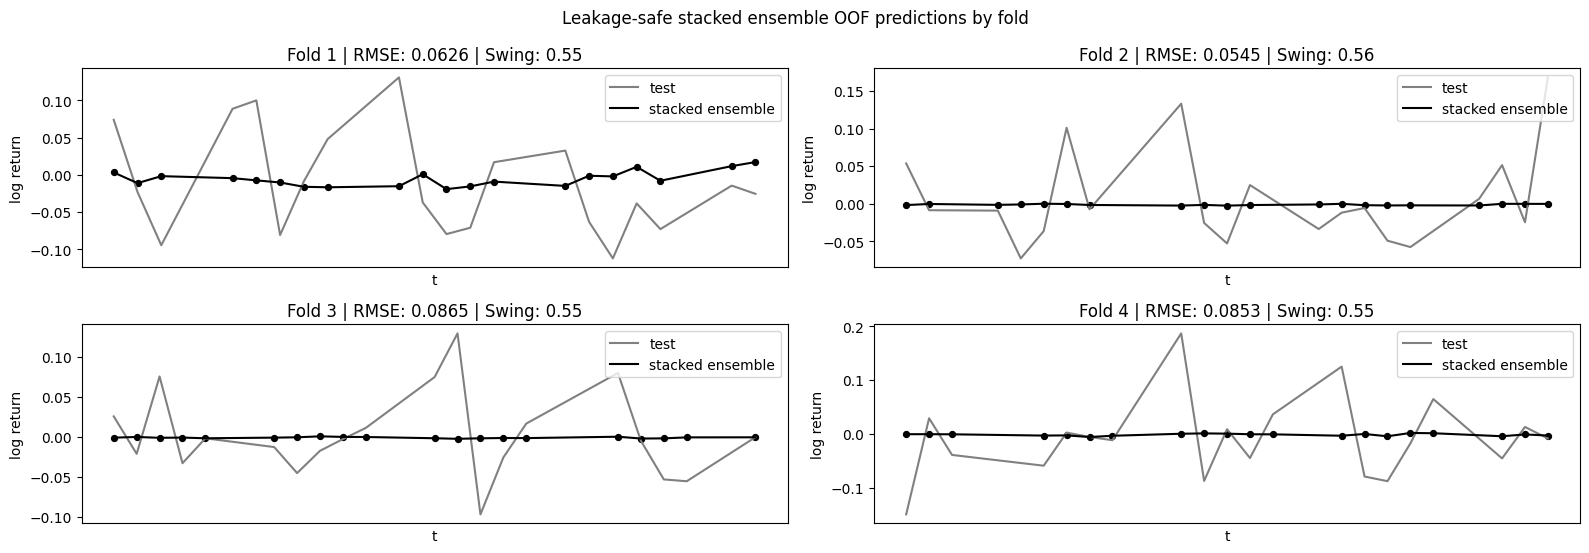

In [11]:
fold_ids = sorted(ensemble_oof_df["fold"].unique())
plot_cols = min(2, max(1, len(fold_ids)))
plot_rows = int(np.ceil(len(fold_ids) / plot_cols))

fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for ax, fold_id in zip(axes, fold_ids):
    fold_df = ensemble_oof_df[ensemble_oof_df["fold"].eq(fold_id)].sort_values("date").head(20)
    fold_metrics = regression_metrics(
        ensemble_oof_df.loc[ensemble_oof_df["fold"].eq(fold_id), "actual"],
        ensemble_oof_df.loc[ensemble_oof_df["fold"].eq(fold_id), "stacked_ensemble_pred"],
    )
    ax.plot(fold_df["date"], fold_df["actual"], color="grey", label="test")
    ax.plot(fold_df["date"], fold_df["stacked_ensemble_pred"], color="black", label="stacked ensemble")
    ax.scatter(fold_df["date"], fold_df["stacked_ensemble_pred"], marker="o", color="black", s=18)
    ax.set_title(
        f"Fold {fold_id} | RMSE: {fold_metrics['rmse']:.4f} | Swing: {fold_metrics['swing_accuracy']:.2f}"
    )
    ax.set_xlabel("t")
    ax.set_ylabel("log return")
    ax.set_xticks([])
    ax.legend(loc="upper right")

for ax in axes[len(fold_ids):]:
    ax.set_visible(False)

plt.suptitle("Leakage-safe stacked ensemble OOF predictions by fold")
plt.tight_layout()
plt.show()


## Meta-Model Coefficients

In [12]:
coef_cols = [f"meta_coef_{col}" for col in BASE_PRED_COLS] + ["meta_intercept"]
meta_coef_df = (
    ensemble_oof_df[["fold", "stacking_mode", *coef_cols]]
    .drop_duplicates()
    .sort_values("fold")
    .reset_index(drop=True)
)
meta_coef_df


,fold,stacking_mode,meta_coef_arimax_pred,meta_coef_xgb_pred,meta_coef_rnn_pred,meta_coef_transformer_pred,meta_intercept
0,1,simple_average_bootstrap,NaN,NaN,NaN,NaN,NaN
1,2,ridge_trained_on_prior_oof,-0.029113,0.023661,0.025049,0.007180,-0.001292
2,3,ridge_trained_on_prior_oof,-0.017161,0.030260,0.046749,0.010454,-0.001524
3,4,ridge_trained_on_prior_oof,-0.061726,0.054885,0.061637,0.041959,-0.000614


## Prediction Export Frame

In [13]:
ensemble_export_df = ensemble_oof_df[
    [
        "date",
        "target_index",
        "fold",
        "actual",
        *BASE_PRED_COLS,
        "simple_average_pred",
        "stacked_ensemble_pred",
        "stacking_mode",
    ]
].copy()

ensemble_export_df.head()


,date,target_index,fold,actual,arimax_pred,xgb_pred,rnn_pred,transformer_pred,simple_average_pred,stacked_ensemble_pred,stacking_mode
0,2022-02-23,7338,1,0.073910,0.017541,0.006111,-0.005158,-0.005366,0.003282,0.003282,simple_average_bootstrap
1,2022-02-24,7339,1,-0.022825,-0.038272,0.010488,-0.007640,-0.008700,-0.011031,-0.011031,simple_average_bootstrap
2,2022-02-25,7340,1,-0.094354,-0.002407,0.005565,-0.004962,-0.004840,-0.001661,-0.001661,simple_average_bootstrap
3,2022-02-28,7341,1,0.088732,-0.012757,-0.003705,0.002691,-0.003585,-0.004339,-0.004339,simple_average_bootstrap
4,2022-03-01,7342,1,0.099973,-0.019877,0.001570,-0.005163,-0.005743,-0.007303,-0.007303,simple_average_bootstrap


# Backtesting

This backtest uses the leakage-safe out-of-fold stacked ensemble predictions. Thresholds are optimized on 2023 SPY using the Sharpe Ratio, then applied to 2024 SPY. Predictions are shifted by one trading day to match the baseline `arima-presentation.ipynb`, RNN, and Transformer backtesting convention.

Open positions are finalized at the end of each backtest so trade counts, stats, and plotted trade markers include positions that are still open on the last bar.


In [14]:
from backtesting import Backtest, Strategy


ENSEMBLE_SIGNAL_COL = "stacked_ensemble_pred"
ENSEMBLE_MODEL_LABEL = "Stacked Ensemble"


class EnsembleVixPredStrategy(Strategy):
    vix_rise_threshold = 0.015   # above this -> expect SPY weakness, close any long
    vix_fall_threshold = -0.015  # below this -> expect SPY strength, enter long

    def init(self):
        self.vix_pred = self.I(func=lambda: self.data.PredVixLogReturn, name="PredVixLogReturn")

    def next(self):
        pred = self.vix_pred[-1]

        if not self.position:
            if pred < self.vix_fall_threshold:
                self.buy()
        else:
            if pred > self.vix_rise_threshold:
                self.position.close()


def fetch_spx(start, end):
    if yq is not None:
        try:
            hist = yq.Ticker("SPY").history(start=start, end=end).reset_index()
            if not hist.empty:
                hist = flatten_yahoo_columns(hist)
                hist["date"] = normalize_dates(hist["date"])
                hist = hist.rename(columns={
                    "open": "Open",
                    "high": "High",
                    "low": "Low",
                    "close": "Close",
                    "volume": "Volume",
                })
                return hist.set_index("date")[["Open", "High", "Low", "Close", "Volume"]].dropna()
        except Exception as exc:
            print(f"yahooquery failed for SPY OHLCV; trying yfinance fallback. Error: {exc}")

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download SPY OHLCV data.")

    hist = yf.download("SPY", start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    hist["date"] = normalize_dates(hist["date"])
    hist = hist.rename(columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
    })
    return hist.set_index("date")[["Open", "High", "Low", "Close", "Volume"]].dropna()


def select_ensemble_prediction_window(prediction_frame, start, end, signal_col=ENSEMBLE_SIGNAL_COL):
    pred = prediction_frame.copy()
    pred["date"] = pd.to_datetime(pred["date"])
    window = pred["date"].ge(pd.Timestamp(start)) & pred["date"].lt(pd.Timestamp(end))
    pred = pred.loc[window].dropna(subset=[signal_col]).sort_values("date").reset_index(drop=True)
    if pred.empty:
        raise ValueError(f"No ensemble predictions available between {start} and {end}.")
    return pred


def attach_ensemble_preds(spx_df, prediction_frame, signal_col=ENSEMBLE_SIGNAL_COL, shift_predictions=True):
    pred_frame = prediction_frame.dropna(subset=["date", signal_col]).copy()
    dates = normalize_dates(pd.Series(pred_frame["date"].values))
    pred_series = pd.Series(pred_frame[signal_col].values, index=dates).sort_index()
    pred_series = pred_series[~pred_series.index.duplicated(keep="last")]
    if shift_predictions:
        pred_series = pred_series.shift(1)

    spx = spx_df[spx_df.index.isin(pred_series.index)].copy()
    spx["PredVixLogReturn"] = pred_series.reindex(spx.index)
    return spx.dropna()


def plot_backtest_equity(test_results, validation_results, model_label):
    fig, ax = plt.subplots(figsize=(10, 4))
    test_equity = test_results["_equity_curve"]["Equity"]
    validation_equity = validation_results["_equity_curve"]["Equity"]
    test_equity.plot(ax=ax, label="2023 threshold-tuning period", color="steelblue")
    validation_equity.plot(ax=ax, label="2024 validation period", color="tomato")

    def nearest_equity_point(equity, timestamp):
        if equity.empty or pd.isna(timestamp):
            return None
        index = pd.DatetimeIndex(equity.index)
        loc = index.get_indexer([pd.Timestamp(timestamp)], method="nearest")[0]
        if loc < 0:
            return None
        return equity.index[loc], float(equity.iloc[loc])

    def add_trade_markers(results, equity, color, label_prefix):
        trades = results.get("_trades", pd.DataFrame())
        if trades is None or len(trades) == 0:
            return

        entry_labeled = False
        exit_labeled = False
        span_labeled = False
        for _, trade in trades.iterrows():
            entry_point = nearest_equity_point(equity, trade.get("EntryTime"))
            exit_point = nearest_equity_point(equity, trade.get("ExitTime"))

            if entry_point is not None and exit_point is not None:
                ax.axvspan(
                    entry_point[0],
                    exit_point[0],
                    color=color,
                    alpha=0.08,
                    label=f"{label_prefix} holding period" if not span_labeled else None,
                )
                span_labeled = True

            if entry_point is not None:
                ax.scatter(
                    entry_point[0],
                    entry_point[1],
                    marker="^",
                    color=color,
                    edgecolor="black",
                    linewidth=0.4,
                    s=58,
                    zorder=5,
                    label=f"{label_prefix} entry" if not entry_labeled else None,
                )
                entry_labeled = True

            if exit_point is not None:
                ax.scatter(
                    exit_point[0],
                    exit_point[1],
                    marker="v",
                    color=color,
                    edgecolor="black",
                    linewidth=0.4,
                    s=58,
                    zorder=5,
                    label=f"{label_prefix} exit" if not exit_labeled else None,
                )
                exit_labeled = True

    add_trade_markers(test_results, test_equity, "steelblue", "test")
    add_trade_markers(validation_results, validation_equity, "tomato", "validation")

    ax.set_title(f"{model_label} VIX-threshold strategy equity")
    ax.set_xlabel("date")
    ax.set_ylabel("account value")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


Loading BokehJS ...

In [15]:
ENSEMBLE_TUNE_START = "2023-01-01"
ENSEMBLE_TUNE_END = "2024-01-01"
ENSEMBLE_VALIDATION_END = "2025-01-01"

ensemble_test_predictions_df = select_ensemble_prediction_window(
    ensemble_oof_df,
    ENSEMBLE_TUNE_START,
    ENSEMBLE_TUNE_END,
)
ensemble_val_predictions_df = select_ensemble_prediction_window(
    ensemble_oof_df,
    ENSEMBLE_TUNE_END,
    ENSEMBLE_VALIDATION_END,
)

spx_test_df = fetch_spx(ENSEMBLE_TUNE_START, ENSEMBLE_TUNE_END)
spx_val_df = fetch_spx(ENSEMBLE_TUNE_END, ENSEMBLE_VALIDATION_END)

spx_test = attach_ensemble_preds(spx_test_df, ensemble_test_predictions_df)
spx_val = attach_ensemble_preds(spx_val_df, ensemble_val_predictions_df)

print(
    f"Threshold-tuning predictions: {len(ensemble_test_predictions_df):,} rows "
    f"from {ensemble_test_predictions_df['date'].min().date()} to {ensemble_test_predictions_df['date'].max().date()} "
    f"using folds {sorted(ensemble_test_predictions_df['fold'].unique())}"
)
print(
    f"Validation predictions: {len(ensemble_val_predictions_df):,} rows "
    f"from {ensemble_val_predictions_df['date'].min().date()} to {ensemble_val_predictions_df['date'].max().date()} "
    f"using folds {sorted(ensemble_val_predictions_df['fold'].unique())}"
)
print(f"SPY backtest rows: tuning={len(spx_test):,}, validation={len(spx_val):,}")


Threshold-tuning predictions: 250 rows from 2023-01-03 to 2023-12-29 using folds [np.int64(1), np.int64(2)]
Validation predictions: 252 rows from 2024-01-02 to 2024-12-31 using folds [np.int64(2), np.int64(3)]
SPY backtest rows: tuning=249, validation=251


Backtest.optimize:   0%|          | 0/36 [00:00<?, ?it/s]






























Backtest.optimize:   8%|▊         | 3/36 [00:00<00:05,  5.79it/s]


























































































Test results
Buy & Hold Return [%]    23.856052
Return [%]               24.260577
Max. Drawdown [%]       -10.258584
Sharpe Ratio               1.55554
# Trades                         3
dtype: object

Validation results
Buy & Hold Return [%]    25.019733
Return [%]                   12.54
Max. Drawdown [%]        -4.119518
Sharpe Ratio              1.387763
# Trades                         1
dtype: object

Best thresholds from 2023: rise=0.01, fall=-0.005


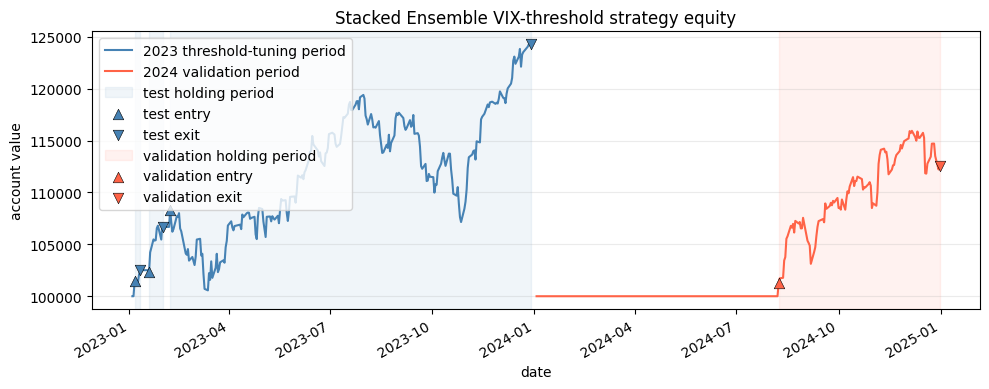

In [16]:
ensemble_bt_test = Backtest(
    spx_test,
    EnsembleVixPredStrategy,
    cash=100_000,
    commission=0,
    exclusive_orders=True,
    finalize_trades=True,
)

ensemble_opt, ensemble_heatmap = ensemble_bt_test.optimize(
    vix_rise_threshold=[0.005, 0.01, 0.02, 0.03, 0.04, 0.05],
    vix_fall_threshold=[-0.05, -0.04, -0.03, -0.02, -0.01, -0.005],
    maximize="Sharpe Ratio",
    constraint=lambda p: p.vix_fall_threshold < p.vix_rise_threshold,
    return_heatmap=True,
)

ensemble_best_rise = ensemble_opt._strategy.vix_rise_threshold
ensemble_best_fall = ensemble_opt._strategy.vix_fall_threshold

ensemble_bt_val = Backtest(
    spx_val,
    EnsembleVixPredStrategy,
    cash=100_000,
    commission=0,
    exclusive_orders=True,
    finalize_trades=True,
)
ensemble_val_results = ensemble_bt_val.run(
    vix_rise_threshold=ensemble_best_rise,
    vix_fall_threshold=ensemble_best_fall,
)

backtest_metrics = ["Buy & Hold Return [%]", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades"]
print("Test results")
print(ensemble_opt[backtest_metrics])
print("\nValidation results")
print(ensemble_val_results[backtest_metrics])
print(f"\nBest thresholds from 2023: rise={ensemble_best_rise}, fall={ensemble_best_fall}")

plot_backtest_equity(ensemble_opt, ensemble_val_results, ENSEMBLE_MODEL_LABEL)
ensemble_bt_val.plot(plot_equity=False, plot_volume=False, plot_return=False);
